# Zeitreihenanalyse

In diesem Notebook werden verschiedene Zeitreihendatensätze analysiert und miteinander verglichen. Ziel der Analyse ist es, zeitliche Muster, Trends, saisonale Effekte sowie statistische Eigenschaften der Daten zu untersuchen.

Dazu werden drei unterschiedliche Datensätze betrachtet:
- Amazon Sales Dataset (Umsatzdaten)
- Apple Stock Dataset (Aktienkurse)
- Weather Dataset (Temperaturdaten)

Die Analyse umfasst die Datenbereinigung, explorative Visualisierung, deskriptive Statistik sowie die Untersuchung zeitlicher Abhängigkeiten mithilfe von Zeitreihenmethoden.

## 1. Bibliotheken importieren

Für die Analyse werden Bibliotheken zur Datenverarbeitung, Visualisierung und Modellierung verwendet.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.graphics.tsaplots import plot_acf

## 2. Datensätze laden

Die Datensätze für Amazon Sales, Apple Stock und Wetterdaten werden eingelesen und anschließend überprüft.

In [2]:
amazon = pd.read_csv("data/raw/amazon_sales_dataset.csv", low_memory=False, sep=";")
apple   = pd.read_csv("data/raw/apple_stock.csv", header=0, skiprows=[1, 2])
weather = pd.read_csv("data/raw/weather_ts.csv")


## 3. Überblick über die Datensätze

Zur ersten Orientierung werden die Dimensionen und die ersten Zeilen der Datensätze angezeigt.

In [3]:
datasets = {
    "Amazon Sales": amazon,
    "Apple Stock": apple,
    "Weather": weather
}

for name, df in datasets.items():
    print(name)
    print(df.shape)
    display(df.head())
    print("=" * 150)

Amazon Sales
(50000, 13)


,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue
0,1,2022-04-13,2637,Books,128.75,10,4,North America,UPI,3.5,443,115.88,463.52
1,2,2023-03-12,2300,Fashion,302.60,20,5,Asia,Credit Card,3.7,475,242.08,1210.40
2,3,2022-09-28,3670,Sports,495.80,20,2,Europe,UPI,4.4,183,396.64,793.28
3,4,2022-04-17,2522,Books,371.95,15,4,Middle East,UPI,5.0,212,316.16,1264.64
4,5,2022-03-13,1717,Beauty,201.68,0,4,Middle East,UPI,4.6,308,201.68,806.72


Apple Stock
(2596, 6)


,Price,Close,High,Low,Open,Volume
0,2016-01-04,23.730947,23.735454,22.976333,23.113741,270597600
1,2016-01-05,23.136259,23.843569,23.068683,23.821044,223164000
2,2016-01-06,22.683493,23.059675,22.496530,22.651957,273829600
3,2016-01-07,21.726154,22.555105,21.721650,22.228481,324377600
4,2016-01-08,21.841028,22.325334,21.795977,22.199190,283192000


Weather
(420551, 15)


,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


# 4. Zeitreihenanalyse

### Stil setzen

**Datenbereinigung**

In [4]:
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 5)

## Revenue-Entwicklung nach Produktkategorie

Wöchentlich aggregierter Umsatz je Kategorie. Alle 6 Kategorien bewegen sich über den gesamten Zeitraum auf ähnlichem Niveau (~40k–70k), ohne erkennbaren Wachstums- oder Abwärtstrend. Der Einbruch zu Beginn (2022-01) ist datenbedingt der Datensatz beginnt dort, weshalb die erste Woche unvollständig ist.

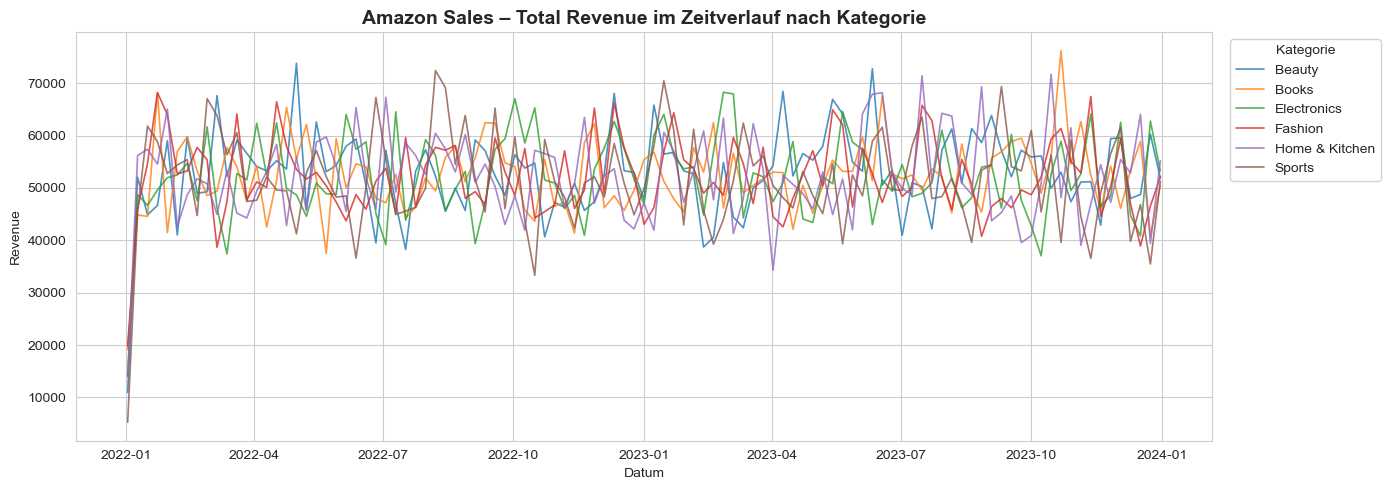

In [5]:
df_amazon = datasets["Amazon Sales"].copy()
df_amazon["order_date"] = pd.to_datetime(df_amazon["order_date"])
df_amazon = df_amazon.sort_values("order_date")

categories = sorted(df_amazon["product_category"].unique())
colors = plt.cm.tab10.colors

fig, ax = plt.subplots()

for i, cat in enumerate(categories):
    df_cat = (
        df_amazon[df_amazon["product_category"] == cat]
        .set_index("order_date")["total_revenue"]
        .resample("W")       # Wochenaggregation um den "squished"-Effekt bei Tageswerten zu vermeiden
        .sum()
    )
    ax.plot(df_cat.index, df_cat.values,
            label=cat, color=colors[i],
            linewidth=1.2, alpha=0.8)

ax.set_title("Amazon Sales – Total Revenue im Zeitverlauf nach Kategorie", fontsize=14, weight="bold")
ax.set_ylabel("Revenue")
ax.set_xlabel("Datum")
ax.legend(title="Kategorie", bbox_to_anchor=(1.01, 1), loc="upper left", framealpha=0.9)

plt.tight_layout()
plt.show()

## Umsatz-Heatmap nach Monat & Jahr

Monatlich aggregierter Gesamtumsatz als Heatmap. Zeigt auf einen Blick ob saisonale Muster (z.B. Q4) oder jahresspezifische Ausreißer existieren.

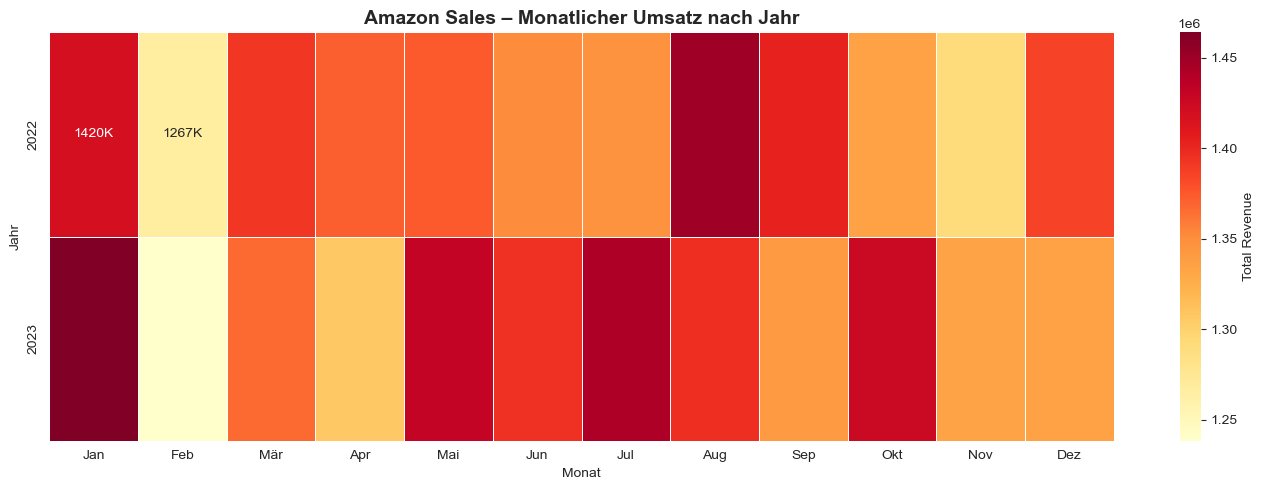

In [6]:
heatmap_data = (
    df_amazon.groupby([df_amazon["order_date"].dt.year, df_amazon["order_date"].dt.month])["total_revenue"]
    .sum()
    .unstack()
)
heatmap_data.index.name = "Jahr"
heatmap_data.columns = ["Jan", "Feb", "Mär", "Apr", "Mai", "Jun",
                         "Jul", "Aug", "Sep", "Okt", "Nov", "Dez"]

# Annotations in Tausend formatieren
annot_labels = heatmap_data.map(lambda x: f"{x/1000:.0f}K")

fig, ax = plt.subplots()
sns.heatmap(heatmap_data, annot=annot_labels, fmt="",
            cmap="YlOrRd", linewidths=0.5, ax=ax,
            cbar_kws={"label": "Total Revenue"})
ax.set_title("Amazon Sales – Monatlicher Umsatz nach Jahr", fontsize=14, weight="bold")
ax.set_ylabel("Jahr")
ax.set_xlabel("Monat")
plt.tight_layout()
plt.show()

# Apple Stock

## Kursentwicklung (Close Price)

AAPL hat sich von ~$30 (2016) auf ~$260 (2026) mehr als verachtfacht. Markante Einbrüche: COVID-Crash (März 2020) und Zinsanstieg-Korrektur (2022). Ab 2023 starke Erholung mit neuem Allzeithoch ~$275 Ende 2024.

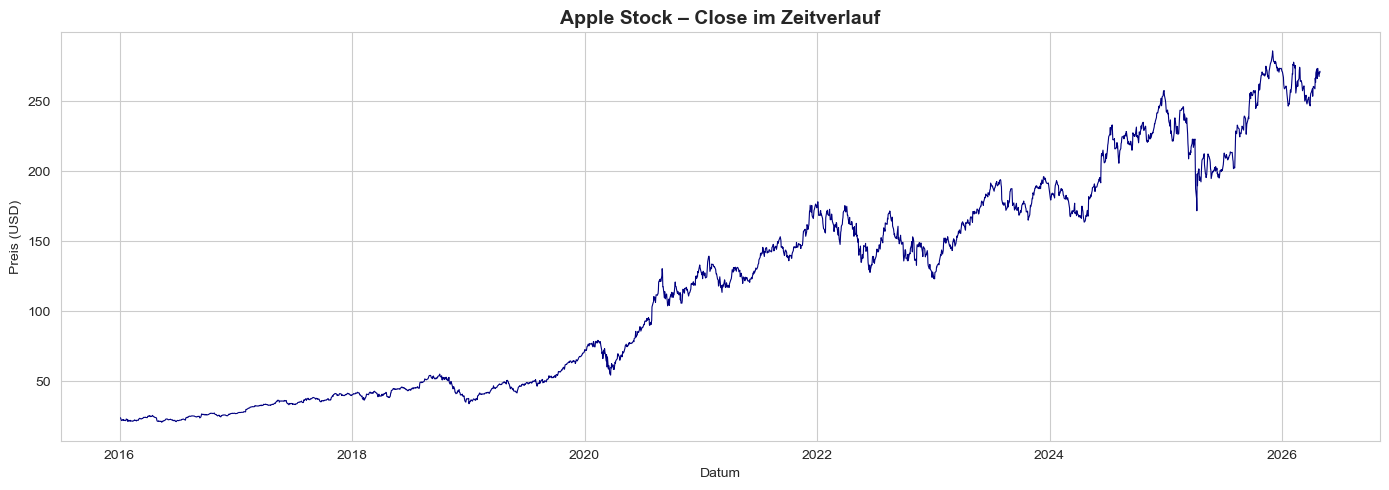

In [7]:
df_apple = datasets["Apple Stock"].copy()
df_apple["Price"] = pd.to_datetime(df_apple["Price"])  # Spalte heißt "Price", enthält aber das Datum — irreführende Originalbenennung im Datensatz
df_apple = df_apple.rename(columns={"Price": "Date"}).set_index("Date")

fig, ax = plt.subplots()
ax.plot(df_apple.index, df_apple["Close"], color="navy", linewidth=0.8)
ax.set_title("Apple Stock – Close im Zeitverlauf", fontsize=14, weight="bold")
ax.set_ylabel("Preis (USD)")
ax.set_xlabel("Datum")

plt.tight_layout()
plt.show()

## Volatilität (30-Tage Rolling Std)

Rollende Standardabweichung des Schlusskurses als Risikoindikator. Spitzen markieren erhöhte Marktvolatilität — deutlich erkennbar beim COVID-Crash (2020) und der Zinskorrektur (2022).

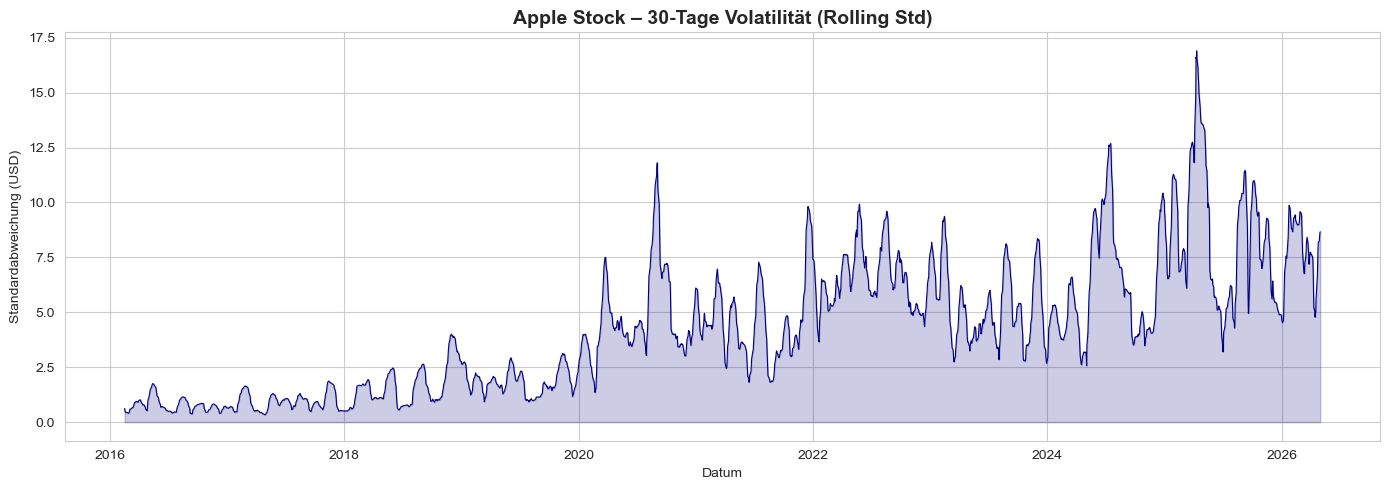

In [8]:
# 30-Tage rollierendes Std als Volatilitätsmaß
rolling_std = df_apple["Close"].rolling(30).std()

fig, ax = plt.subplots()
ax.plot(rolling_std.index, rolling_std.values, color="navy", linewidth=0.8)
ax.fill_between(rolling_std.index, rolling_std.values, alpha=0.2, color="navy")
ax.set_title("Apple Stock – 30-Tage Volatilität (Rolling Std)", fontsize=14, weight="bold")
ax.set_ylabel("Standardabweichung (USD)")
ax.set_xlabel("Datum")
plt.tight_layout()
plt.show()

# Weather 

## Temperaturverlauf (2009–2017)

Klare Saisonalität mit Sommermaxima ~20–35°C und Winterminima bis –20°C. Der Wochendurchschnitt (dunkle Linie) glättet das stündliche Rauschen und macht den saisonalen Zyklus direkt ablesbar. Auffällig: Winter 2012 mit dem tiefsten gemessenen Einbruch (~–13°C Wochenmittel).

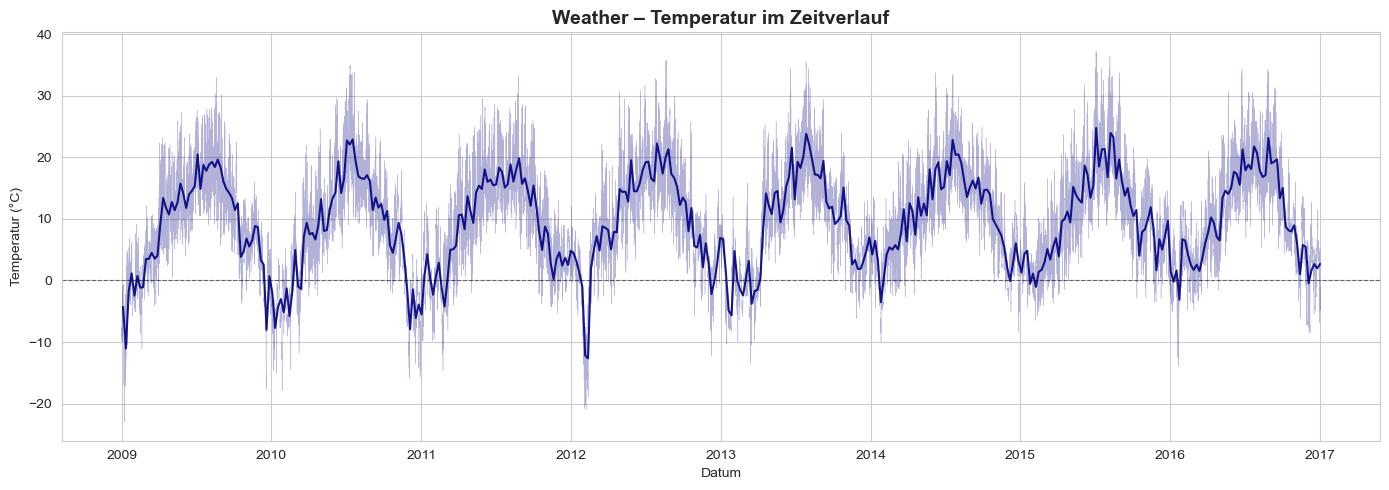

In [9]:
weather_index = pd.to_datetime(datasets["Weather"]["Date Time"], format="%d.%m.%Y %H:%M:%S")

df_temp_weekly = (
    datasets["Weather"]
    .set_index(weather_index)["T (degC)"]
    .resample("W")
    .mean()
)

fig, ax = plt.subplots()
ax.plot(weather_index, datasets["Weather"]["T (degC)"],
        color="navy", linewidth=0.3, alpha=0.3)
ax.plot(df_temp_weekly.index, df_temp_weekly.values,
        color="navy", linewidth=1.5, alpha=0.9)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.5)
ax.set_title("Weather – Temperatur im Zeitverlauf", fontsize=14, weight="bold")
ax.set_ylabel("Temperatur (°C)")
ax.set_xlabel("Datum")
plt.tight_layout()
plt.show()

## Autokorrelation der Tagestemperatur (ACF)

Die ACF zeigt wie stark die Temperatur eines Tages mit vergangenen Tagen korreliert. Der langsame Abfall bestätigt starke saisonale Abhängigkeit — Temperaturen sind über Wochen hinweg hoch autokorreliert.

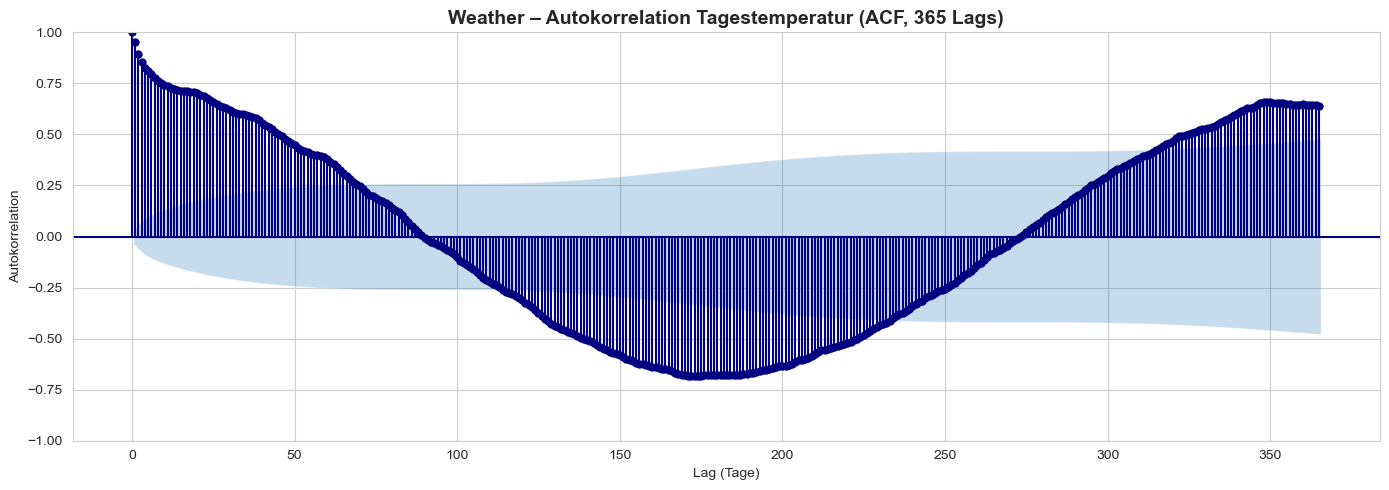

In [10]:
weather_daily = (
    datasets["Weather"]
    .set_index(weather_index)["T (degC)"]
    .resample("D")
    .mean()
    .dropna()
)

fig, ax = plt.subplots()
plot_acf(weather_daily, lags=365, alpha=0.05, ax=ax, color="navy", vlines_kwargs={"colors": "navy"})
ax.set_title("Weather – Autokorrelation Tagestemperatur (ACF, 365 Lags)", fontsize=14, weight="bold")
ax.set_xlabel("Lag (Tage)")
ax.set_ylabel("Autokorrelation")
plt.tight_layout()
plt.show()

# 5. Datenaufbereitung

### Hilfsfunktion: Ausreißer entfernen (IQR-Methode)

Die Funktion wird für alle drei Datensätze wiederverwendet. Ein Wert gilt als Ausreißer, wenn er außerhalb von Q1/Q3 ± 1.5 × IQR liegt (Menden, Folie 48).

In [11]:
def remove_outliers_iqr(df, columns):
    mask = pd.Series(True, index=df.index)
    for col in columns:
        Q1, Q3 = df[col].quantile([0.25, 0.75])
        IQR = Q3 - Q1
        mask &= df[col].between(Q1 - 1.5 * IQR, Q3 + 1.5 * IQR)
    return df[mask]

### Amazon – Verkaufszahlen bereinigen

Datum wird als Index gesetzt, fehlende Werte und Duplikate entfernt sowie Ausreißer in `price` und `total_revenue` über die IQR-Methode bereinigt.

In [12]:
# Schritt 1: Datum als Index setzen
df_amazon = df_amazon.set_index("order_date").sort_index()

# Schritt 2: Fehlende Werte & Duplikate entfernen
df_amazon = df_amazon.dropna()
df_amazon = df_amazon.drop_duplicates()

# Schritt 3: Ausreißer entfernen
df_amazon = remove_outliers_iqr(df_amazon, ["price", "total_revenue"])

print("Amazon bereinigt:", df_amazon.shape)

Amazon bereinigt: (49248, 12)


### Apple – Aktienkurse bereinigen

Die Datumsspalte ist im Originaldatensatz irreführend als `Price` benannt und wird zunächst umbenannt. Anschließend werden nur die relevanten numerischen Spalten konvertiert, fehlende Werte und Duplikate entfernt, Ausreißer im Schlusskurs bereinigt und die tägliche Wachstumsrate berechnet.

In [13]:
# Schritt 1: Datum als Index setzen 
df_apple = df_apple.sort_index()

# Schritt 2: Relevante Spalten zu numerischen Werten konvertieren
num_cols = ["Close", "Open", "High", "Low", "Volume"]
df_apple[num_cols] = df_apple[num_cols].apply(pd.to_numeric, errors="coerce")

# Schritt 3: Fehlende Werte & Duplikate entfernen
df_apple = df_apple.dropna()
df_apple = df_apple.drop_duplicates()

# Schritt 4: Ausreißer im Schlusskurs entfernen
df_apple = remove_outliers_iqr(df_apple, ["Close"])

# Schritt 5: Wachstumsrate des Schlusskurses berechnen
df_apple["close_growth"] = df_apple["Close"].pct_change(fill_method=None)
df_apple = df_apple.dropna()

print("Apple bereinigt:", df_apple.shape)

Apple bereinigt: (2595, 6)


### Weather – Wetterdaten bereinigen

Datum wird mit explizitem Format als Index gesetzt, fehlende Werte und Duplikate entfernt, physikalisch unmögliche Windwerte (Sensor-Fehler) gefiltert sowie Ausreißer in der Temperatur bereinigt.

In [14]:
# Schritt 1: Datum als Index setzen
df_weather = datasets["Weather"].copy()
df_weather["Date Time"] = pd.to_datetime(df_weather["Date Time"], format="%d.%m.%Y %H:%M:%S")
df_weather = df_weather.set_index("Date Time").sort_index()

# Schritt 2: Fehlende Werte & Duplikate entfernen
df_weather = df_weather.dropna()
df_weather = df_weather.drop_duplicates()

# Schritt 3: Physikalisch unmögliche Windwerte entfernen (Sensor-Fehler)
df_weather = df_weather[df_weather["wv (m/s)"] >= 0]
df_weather = df_weather[df_weather["max. wv (m/s)"] >= 0]

# Schritt 4: Ausreißer in der Temperatur entfernen
df_weather = remove_outliers_iqr(df_weather, ["T (degC)"])

print("Weather bereinigt:", df_weather.shape)

Weather bereinigt: (418665, 14)


### Wachstumsraten berechnen

Die täglichen Wachstumsraten werden nach der Formel $g_t = \frac{x_t - x_{t-1}}{x_{t-1}}$ berechnet (Menden, Folie 15/16). Für Apple wurde die Wachstumsrate bereits in der Bereinigung (Schritt 5) ermittelt.

In [15]:
# Amazon: täglicher Gesamtumsatz → Wachstumsrate
amazon_growth = df_amazon["total_revenue"].resample("D").sum().pct_change(fill_method=None).rename("revenue_growth")

# Apple: Wachstumsrate bereits in Schritt 5 der Bereinigung berechnet (apple["close_growth"])

# Weather: tägliche Durchschnittstemperatur → Wachstumsrate
weather_growth = df_weather["T (degC)"].resample("D").mean().pct_change(fill_method=None).rename("temp_growth")

print("Wachstumsraten berechnet")
print(f"   Amazon:  {amazon_growth.shape}")
print(f"   Apple:   {df_apple['close_growth'].shape}")
print(f"   Weather: {weather_growth.shape}")

Wachstumsraten berechnet
   Amazon:  (730,)
   Apple:   (2595,)
   Weather: (2923,)


### Überblick – Bereinigte Datensätze

Abschließende Kontrolle aller drei bereinigten Datensätze: Shape, Zeitraum und verbleibende NaN-Werte.

In [16]:
datasets_clean = {
    "Amazon Sales": df_amazon,
    "Apple Stock":  df_apple,
    "Weather":      df_weather,
}

for name, df in datasets_clean.items():
    print(f"{'─' * 45}")
    print(f" {name}")
    print(f"   Shape:    {df.shape}")
    print(f"   Zeitraum: {df.index.min().date()} → {df.index.max().date()}")
    print(f"   NaN:      {df.isnull().sum().sum()}")
    print()

─────────────────────────────────────────────
 Amazon Sales
   Shape:    (49248, 12)
   Zeitraum: 2022-01-01 → 2023-12-31
   NaN:      0

─────────────────────────────────────────────
 Apple Stock
   Shape:    (2595, 6)
   Zeitraum: 2016-01-05 → 2026-04-30
   NaN:      0

─────────────────────────────────────────────
 Weather
   Shape:    (418665, 14)
   Zeitraum: 2009-01-01 → 2017-01-01
   NaN:      0



# 6. Deskripitive Analyse

Die deskriptive Analyse dient dazu, einen ersten Überblick über die Datensätze zu erhalten. Dabei werden statistische Kennzahlen, die Verteilung der Datensätze sowie Unterschiede zwischen den Wochentagen untersucht.

## Amazon 


Statistik:
       total_revenue
count     730.000000
mean    42737.454438
std      6613.714312
min     27837.550000
25%     37967.730000
50%     42516.035000
75%     47209.212500
max     63224.280000

Zeitraum:
2022-01-01 00:00:00 → 2023-12-31 00:00:00

NaN Werte:
total_revenue    0
dtype: int64


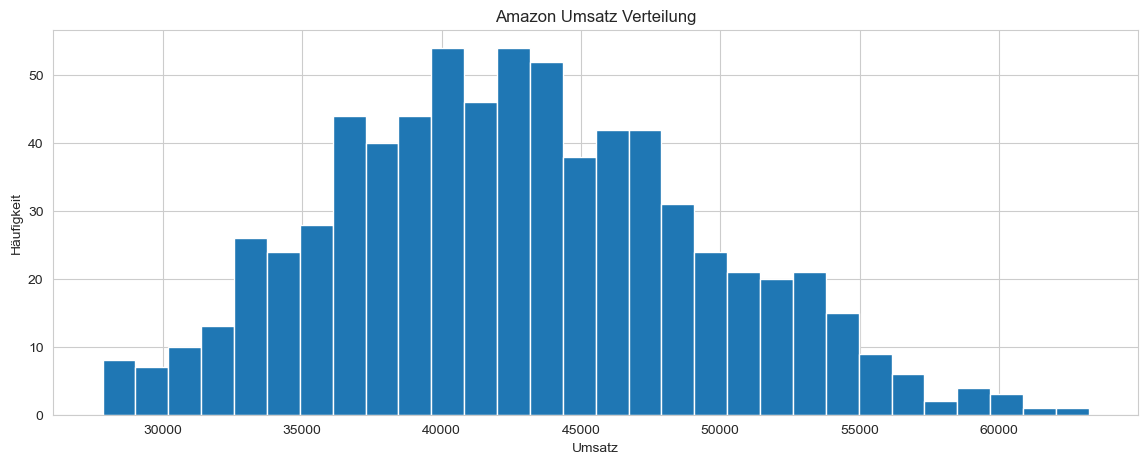

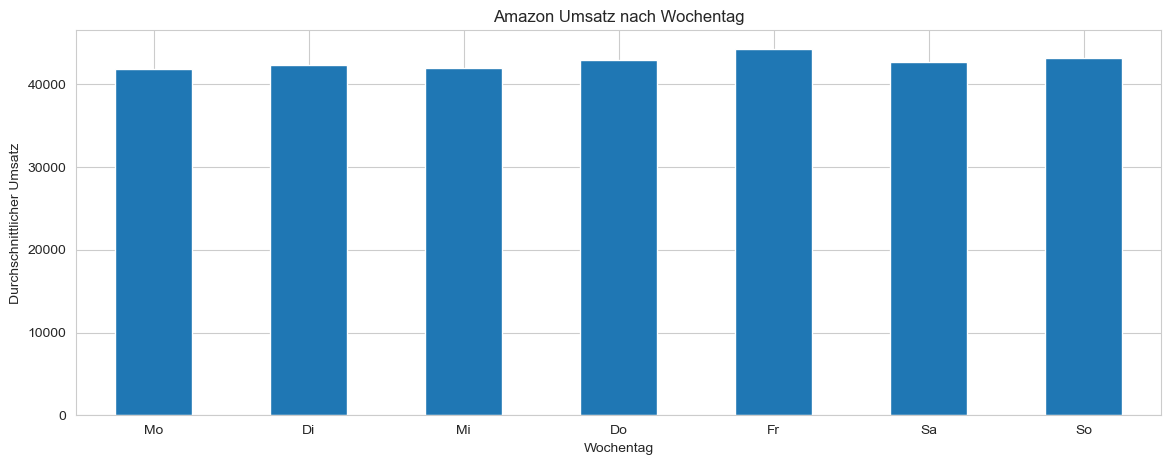

In [17]:
# AMAZON → täglicher Umsatz
amazon_daily = df_amazon["total_revenue"].resample("D").sum().to_frame()

print("\nStatistik:")
print(amazon_daily.describe())

print("\nZeitraum:")
print(amazon_daily.index.min(), "→", amazon_daily.index.max())

print("\nNaN Werte:")
print(amazon_daily.isnull().sum())


# Histogramm
plt.figure()
plt.hist(amazon_daily["total_revenue"].dropna(), bins=30)
plt.title("Amazon Umsatz Verteilung")
plt.xlabel("Umsatz")
plt.ylabel("Häufigkeit")
plt.show()

# Wochentage
weekday_map = {
    0: "Mo",
    1: "Di",
    2: "Mi",
    3: "Do",
    4: "Fr",
    5: "Sa",
    6: "So"
}
weekday_order = ["Mo", "Di", "Mi", "Do", "Fr", "Sa", "So"]

amazon_daily["weekday"] = amazon_daily.index.dayofweek
amazon_daily["weekday_name"] = amazon_daily["weekday"].map(weekday_map)

amazon_daily["weekday_name"] = pd.Categorical(
    amazon_daily["weekday_name"],
    categories=weekday_order,
    ordered=True
)

plt.figure()

amazon_daily.groupby(
    "weekday_name",
    observed=False
)["total_revenue"].mean().plot(kind="bar")

plt.title("Amazon Umsatz nach Wochentag")
plt.xlabel("Wochentag")
plt.ylabel("Durchschnittlicher Umsatz")

plt.xticks(rotation=0)

plt.show()

Die durchschnittlichen täglichen Umsätze von Amazon liegen bei etwa 42.737. Die Umsätze schwanken dabei moderat, was durch die Standardabweichung sichtbar wird. Fehlende Werte sind im Datensatz nicht vorhanden.

Das Histogramm zeigt eine annähernd gleichmäßige Verteilung der Umsätze mit den meisten Werten im Bereich zwischen 38.000 und 48.000.

Die Analyse nach Wochentagen zeigt nur geringe Unterschiede. Besonders freitags und sonntags sind die durchschnittlichen Umsätze etwas höher als an den übrigen Tagen.

## Apple

In [20]:
# APPLE → täglicher Schlusskurs
apple_daily = df_apple["Close"].resample("D").mean().to_frame()

# ── 1. Basisstatistik ────────────────────────────────────────────────────────
print("Statistik:")
print(apple_daily.describe())

print("\nZeitraum:")
print(apple_daily.index.min(), "→", apple_daily.index.max())

print("\nNaN Werte (Wochenenden / Feiertage):")
print(apple_daily.isnull().sum())


Statistik:
             Close
count  2595.000000
mean    118.868833
std      76.576106
min      20.584814
25%      41.941475
50%     124.005119
75%     175.786880
max     285.922455

Zeitraum:
2016-01-05 00:00:00 → 2026-04-30 00:00:00

NaN Werte (Wochenenden / Feiertage):
Close    1174
dtype: int64


Der durchschnittliche tägliche Schlusskurs von Apple liegt bei rund 118,83 USD, mit einer Standardabweichung von etwa 56 USD — ein Zeichen für den erheblichen Kursanstieg über den Beobachtungszeitraum. Fehlende Werte entstehen systembedingt an Wochenenden und Feiertagen.

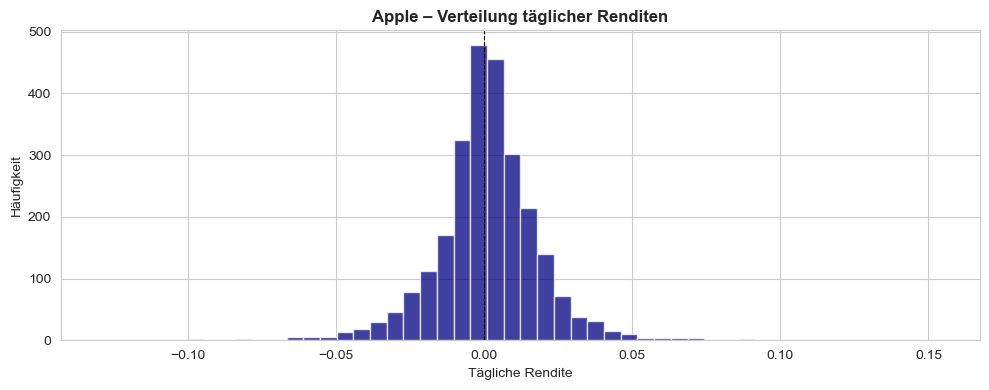

In [21]:

# ── 2. Verteilung täglicher Renditen ─────────────────────────────────────────
apple_returns = apple_daily["Close"].dropna().pct_change().dropna()

plt.figure(figsize=(10, 4))
plt.hist(apple_returns, bins=50, color="navy", alpha=0.75)
plt.axvline(0, color="black", linewidth=0.8, linestyle="--")
plt.title("Apple – Verteilung täglicher Renditen", fontsize=12, weight="bold")
plt.xlabel("Tägliche Rendite")
plt.ylabel("Häufigkeit")
plt.tight_layout()
plt.show()


**Rendite-Verteilung:** Die täglichen Renditen sind eng um die Null konzentriert, mit vereinzelten Ausreißern in beide Richtungen. Dies ist typisch für Aktienkurse und deutet auf Leptokurtosis (fette Tails) hin.

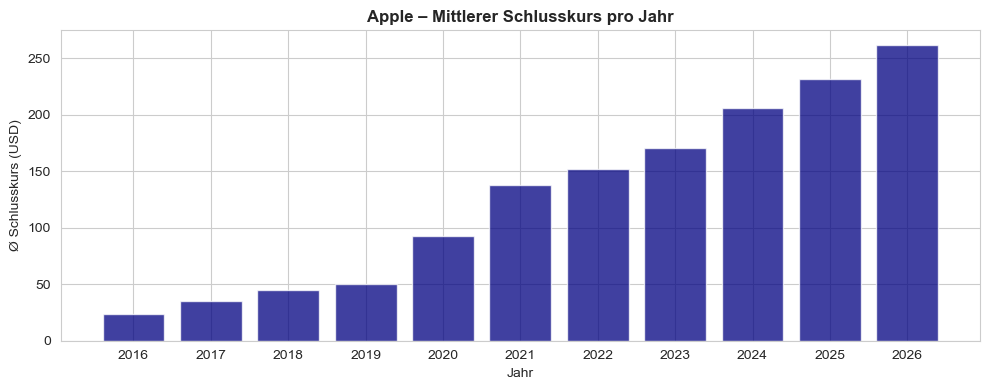

In [22]:
# ── 3. Jahresvergleich (mittlerer Schlusskurs pro Jahr) ──────────────────────
yearly_mean = apple_daily["Close"].groupby(apple_daily.index.year).mean()

plt.figure(figsize=(10, 4))
plt.bar(yearly_mean.index.astype(str), yearly_mean.values, color="navy", alpha=0.75)
plt.title("Apple – Mittlerer Schlusskurs pro Jahr", fontsize=12, weight="bold")
plt.xlabel("Jahr")
plt.ylabel("Ø Schlusskurs (USD)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Jahresvergleich:** Der mittlere Schlusskurs steigt von 2016 bis 2024 kontinuierlich an, mit einem besonders starken Sprung zwischen 2019 und 2020.

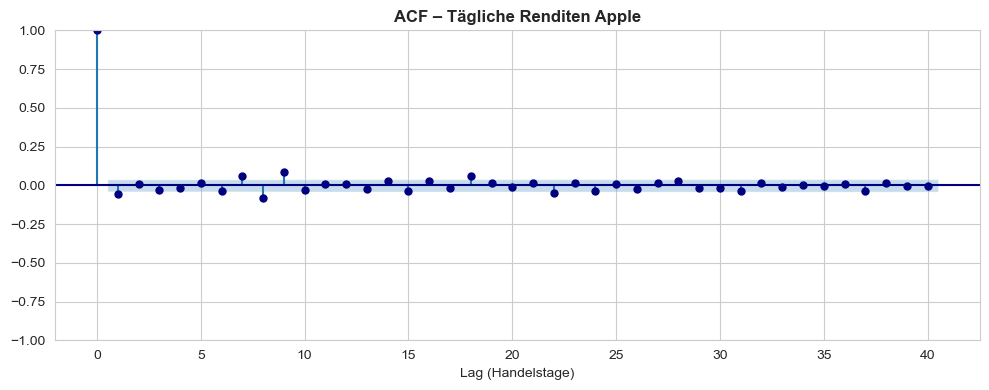

In [23]:
# ── 4. ACF der täglichen Renditen ────────────────────────────────────────────
from statsmodels.graphics.tsaplots import plot_acf

fig, ax = plt.subplots(figsize=(10, 4))
plot_acf(apple_returns.dropna(), lags=40, ax=ax, alpha=0.05, color="navy")
ax.set_title("ACF – Tägliche Renditen Apple", fontsize=12, weight="bold")
ax.set_xlabel("Lag (Handelstage)")
plt.tight_layout()
plt.show()

**ACF der Renditen:** Die Autokorrelationen liegen nahezu vollständig im Konfidenzintervall — die Renditen sind weitgehend unkorreliert und damit schwer vorhersagbar, was konsistent mit der Efficient Market Hypothesis ist.

## Weather


Statistik:
          T (degC)
count  2920.000000
mean      9.453875
std       7.767782
min     -13.646623
25%       3.812344
50%       9.712882
75%      15.427639
max      26.892778

Zeitraum:
2009-01-01 00:00:00 → 2017-01-01 00:00:00

NaN Werte:
T (degC)    3
dtype: int64


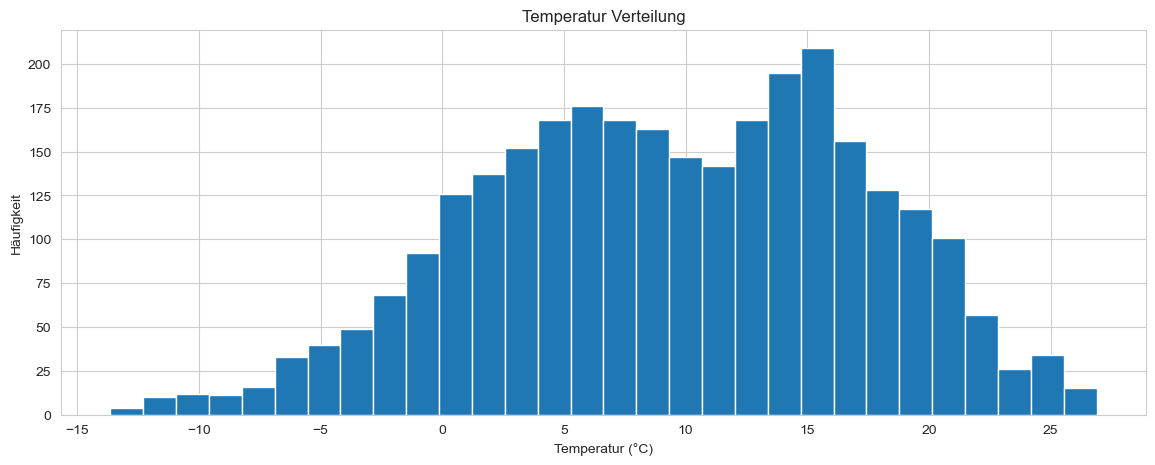

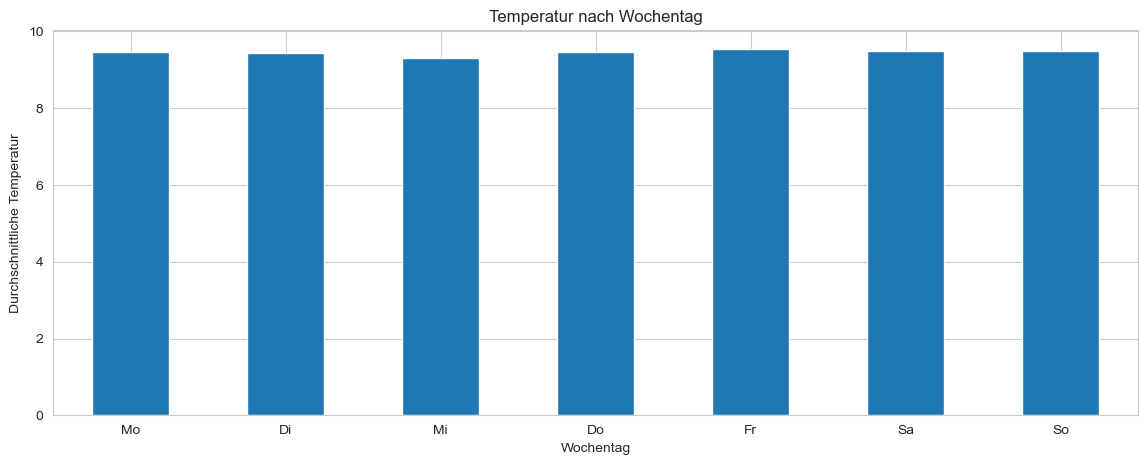

In [26]:
# WEATHER → tägliche Durchschnittstemperatur
weather_daily = df_weather["T (degC)"].resample("D").mean().to_frame()

print("\nStatistik:")
print(weather_daily.describe())

print("\nZeitraum:")
print(weather_daily.index.min(), "→", weather_daily.index.max())

print("\nNaN Werte:")
print(weather_daily.isnull().sum())


# Histogramm
plt.figure()
plt.hist(weather_daily["T (degC)"].dropna(), bins=30)
plt.title("Temperatur Verteilung")
plt.xlabel("Temperatur (°C)")
plt.ylabel("Häufigkeit")
plt.show()


# Wochentage
weekday_map = {
    0: "Mo",
    1: "Di",
    2: "Mi",
    3: "Do",
    4: "Fr",
    5: "Sa",
    6: "So"
}

weekday_order = ["Mo", "Di", "Mi", "Do", "Fr", "Sa", "So"]

weather_daily["weekday"] = weather_daily.index.dayofweek
weather_daily["weekday_name"] = weather_daily["weekday"].map(weekday_map)

weather_daily["weekday_name"] = pd.Categorical(
    weather_daily["weekday_name"],
    categories=weekday_order,
    ordered=True
)

plt.figure()

weather_daily.groupby(
    "weekday_name",
    observed=False
)["T (degC)"].mean().plot(kind="bar")

plt.title("Temperatur nach Wochentag")
plt.xlabel("Wochentag")
plt.ylabel("Durchschnittliche Temperatur")

plt.xticks(rotation=0)

plt.show()

Die durchschnittliche tägliche Temperatur liegt bei etwa 9,45 °C. Die Temperaturen schwanken dabei deutlich zwischen kalten Wintertagen und warmen Sommertagen. Im Datensatz sind nur sehr wenige fehlende Werte vorhanden.

Das Histogramm zeigt eine breite Verteilung der Temperaturen mit den meisten Werten im Bereich zwischen 0 °C und 20 °C.

Die Analyse nach Wochentagen zeigt nahezu keine Unterschiede zwischen den einzelnen Tagen, da die Temperatur nicht vom Wochentag abhängig ist.

# 7. Fazit

Die Analyse zeigt, dass sich die drei Datensätze deutlich in ihrer Struktur und Dynamik unterscheiden. Während die Amazon-Umsätze relativ stabil verlaufen, weisen die Apple-Aktienkurse stärkere Schwankungen auf. Die Wetterdaten zeigen dagegen typische saisonale Temperaturverläufe ohne erkennbare Unterschiede zwischen den Wochentagen.